In [2528]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from xgboost import plot_importance
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [2529]:
high = pd.read_csv('neonatal_high_burden.csv')
high.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome
0,1,F,35.0,2610,42.0,24,2,vaginal,6,8,37.1,143,55,94,Normal_BW,Late_preterm,healthy
1,2,M,37.6,2490,39.4,15,0,vaginal,8,7,37.3,125,48,97,LBW,Term,neonatal_sepsis
2,3,F,36.6,2500,20.2,27,1,vaginal,8,4,37.0,129,45,98,Normal_BW,Late_preterm,healthy
3,4,F,39.0,3230,42.0,31,4,vaginal,9,7,36.9,149,37,98,Normal_BW,Term,healthy
4,5,M,38.1,3470,37.2,27,0,vaginal,7,10,36.8,181,52,96,Normal_BW,Term,healthy


In [2530]:
low = pd.read_csv('neonatal_low_burden.csv')
low.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome
0,1,F,36.3,2860,39.8,24,2,vaginal,7,6,36.8,134,45,97,Normal_BW,Late_preterm,healthy
1,2,M,37.8,2640,34.0,15,0,vaginal,9,9,36.5,144,53,95,Normal_BW,Term,healthy
2,3,F,39.6,3010,41.4,27,1,vaginal,9,10,37.2,149,55,98,Normal_BW,Term,healthy
3,4,F,39.0,3230,34.6,31,4,vaginal,9,9,36.7,160,51,98,Normal_BW,Term,healthy
4,5,M,39.0,3630,35.2,27,0,caesarean,9,9,36.9,147,43,98,Normal_BW,Term,healthy


In [2531]:
moderate = pd.read_csv('neonatal_moderate_burden.csv')
moderate.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome
0,1,F,35.4,2690,26.6,24,2,vaginal,6,3,37.2,154,53,97,Normal_BW,Late_preterm,healthy
1,2,M,37.1,2830,38.5,15,0,vaginal,4,4,36.9,93,44,83,Normal_BW,Term,birth_asphyxia
2,3,F,37.1,2600,36.3,27,1,vaginal,10,8,36.8,120,51,94,Normal_BW,Term,healthy
3,4,F,39.3,3280,34.9,31,4,vaginal,9,7,37.1,141,54,95,Normal_BW,Term,healthy
4,5,M,38.5,3540,42.0,27,0,vaginal,8,9,37.0,157,49,99,Normal_BW,Term,healthy


In [2532]:
# Add a new column to each DataFrame to indicate the burden level
high["burden_level"] = "high"
low["burden_level"] = "low"
moderate["burden_level"] = "moderate"

# Combine the DataFrames into a single DataFrame
df = pd.concat([high, low, moderate], axis=0)

# Shuffle the combined DataFrame
df = df.sample(frac=1, random_state=52).reset_index(drop=True)

#Moving primary outcome to the end of the DataFrame
cols = [col for col in high.columns if col != "primary_outcome"] + ["primary_outcome"]
df = df[cols]

df.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,burden_level,primary_outcome
0,7968,F,38.2,2730,37.0,16,0,vaginal,9,10,36.7,147,48,96,Normal_BW,Term,moderate,healthy
1,5442,F,39.8,2260,34.8,17,0,vaginal,5,9,36.7,125,43,97,LBW,Term,high,low_birth_weight_term
2,2705,F,37.1,3030,39.4,20,2,vaginal,9,9,36.4,120,47,97,Normal_BW,Term,high,healthy
3,7886,M,39.7,3130,18.1,15,0,vaginal,8,10,36.8,143,54,96,Normal_BW,Term,moderate,healthy
4,3572,M,40.5,2870,34.1,23,1,vaginal,8,7,37.2,108,46,97,Normal_BW,Term,low,low_birth_weight_term


In [2533]:
df.describe()

,id,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000
mean,5000.500000,37.896707,2851.544667,32.732983,25.813900,2.478700,7.432033,8.040633,36.738807,138.956867,49.101567,96.14820
std,2886.799445,2.578925,600.447582,7.761193,5.678762,2.124028,1.946546,1.835346,0.562219,15.350728,7.761056,3.05406
min,1.000000,24.100000,400.000000,18.000000,14.000000,0.000000,0.000000,0.000000,34.000000,61.000000,27.000000,73.00000
25%,2500.750000,36.700000,2480.000000,26.900000,22.000000,1.000000,7.000000,7.000000,36.600000,130.000000,44.000000,95.00000
50%,5000.500000,38.300000,2890.000000,33.600000,26.000000,2.000000,8.000000,9.000000,36.800000,140.000000,48.000000,97.00000
75%,7500.250000,39.700000,3270.000000,40.500000,30.000000,4.000000,9.000000,9.000000,37.100000,149.000000,53.000000,98.00000
max,10000.000000,42.000000,4970.000000,42.000000,47.000000,14.000000,10.000000,10.000000,39.500000,196.000000,100.000000,100.00000


In [2534]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [2535]:
# Check for missing values
df.isnull().sum()

id                       0
sex                      0
gestational_age_weeks    0
birth_weight_g           0
head_circumference_cm    0
maternal_age_years       0
parity                   0
delivery_mode            0
apgar_1min               0
apgar_5min               0
temperature_c            0
heart_rate_bpm           0
respiratory_rate_bpm     0
spo2_percent             0
bw_category              0
preterm_category         0
burden_level             0
primary_outcome          0
dtype: int64

In [2536]:
df.shape

(30000, 18)

In [2537]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     30000 non-null  int64  
 1   sex                    30000 non-null  object 
 2   gestational_age_weeks  30000 non-null  float64
 3   birth_weight_g         30000 non-null  int64  
 4   head_circumference_cm  30000 non-null  float64
 5   maternal_age_years     30000 non-null  int64  
 6   parity                 30000 non-null  int64  
 7   delivery_mode          30000 non-null  object 
 8   apgar_1min             30000 non-null  int64  
 9   apgar_5min             30000 non-null  int64  
 10  temperature_c          30000 non-null  float64
 11  heart_rate_bpm         30000 non-null  int64  
 12  respiratory_rate_bpm   30000 non-null  int64  
 13  spo2_percent           30000 non-null  int64  
 14  bw_category            30000 non-null  object 
 15  pr

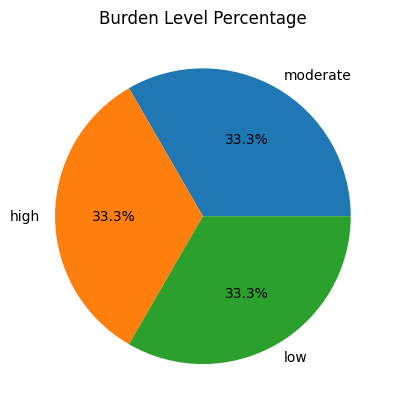

In [2538]:
# Visualize the distribution of the burden levels
df["burden_level"].value_counts().plot.pie(autopct="%1.1f%%")
plt.ylabel("")
plt.title("Burden Level Percentage")
plt.show()

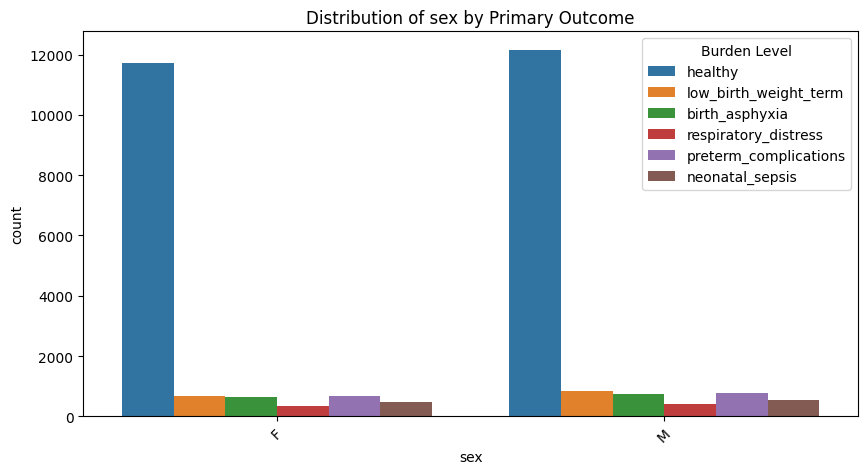

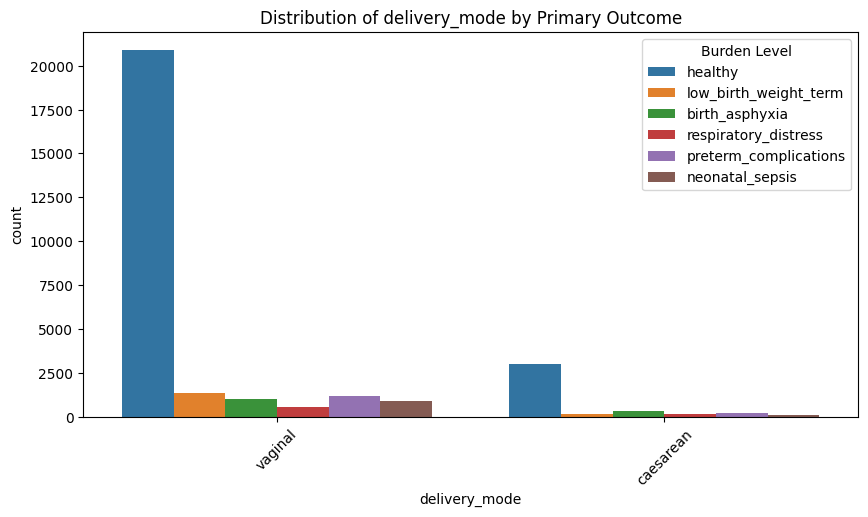

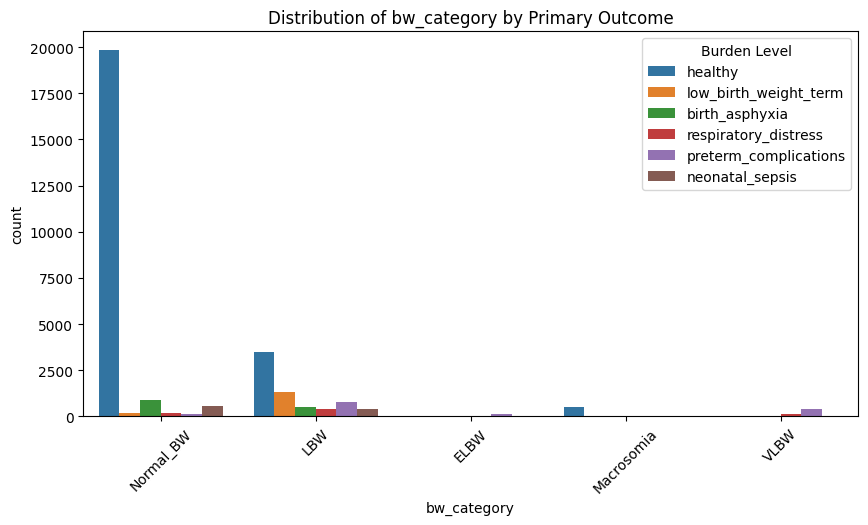

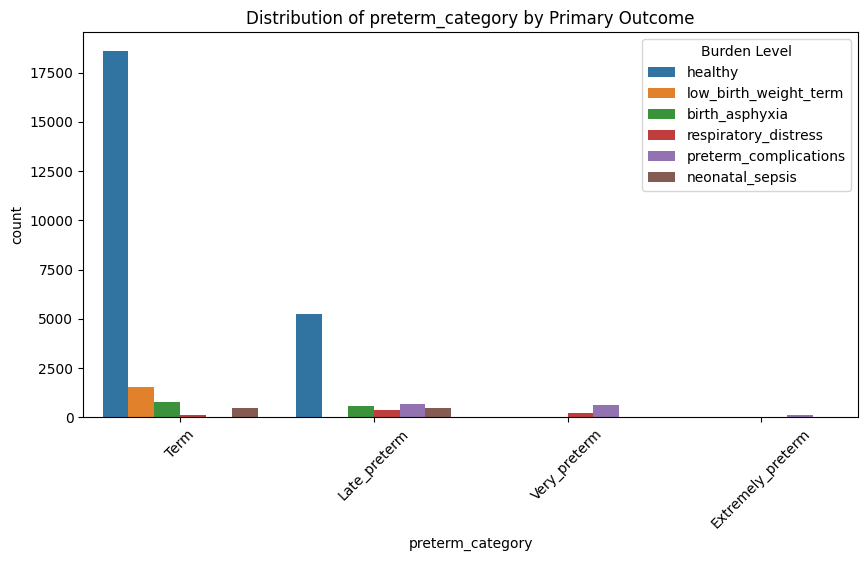

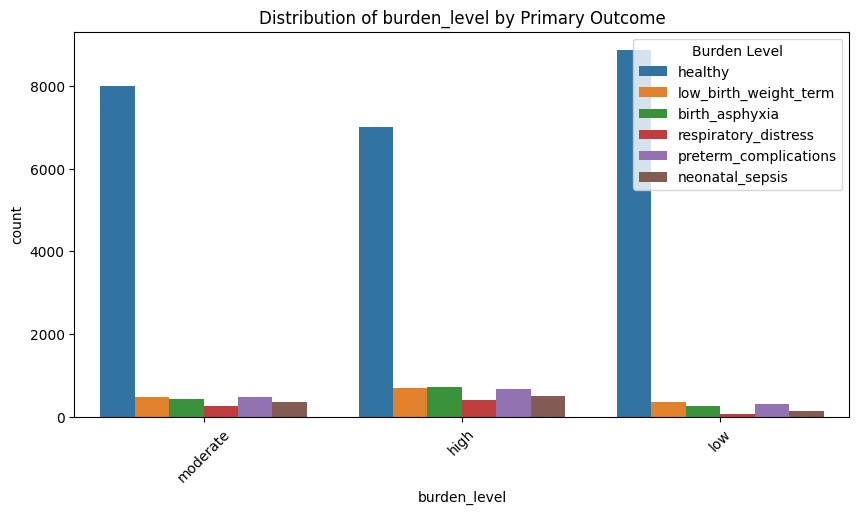

C:\Users\mable\AppData\Local\Temp\ipykernel_19552\1524686404.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Burden Level")


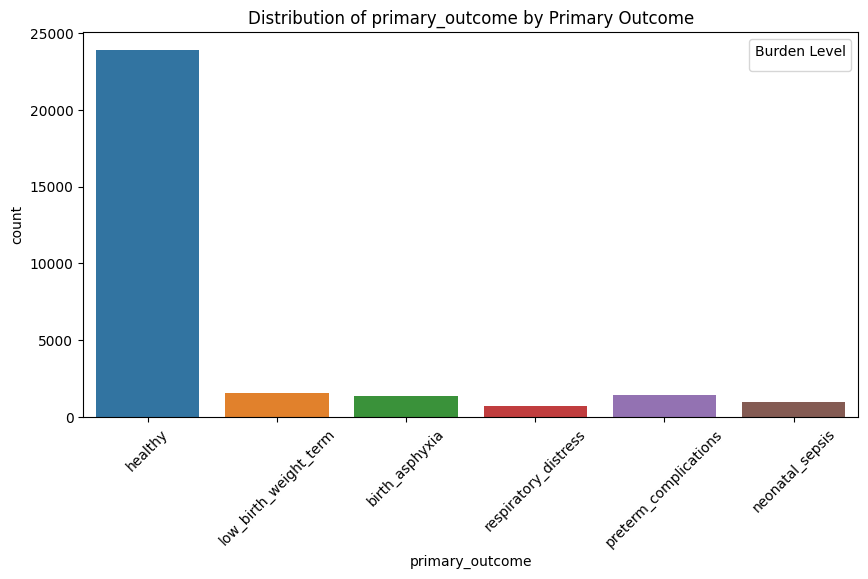

In [2539]:
# Categorical features
categorical_features = df.select_dtypes(include=["object"]).columns
for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=feature, hue="primary_outcome")
    plt.title(f"Distribution of {feature} by Primary Outcome")
    plt.xticks(rotation=45)
    plt.legend(title="Burden Level")
    plt.show()

In [2540]:
#Convert delivery mode to numerical values
df["delivery_mode"] = df["delivery_mode"].map({"vaginal": 0, "caesarean": 1})
df.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,burden_level,primary_outcome
0,7968,F,38.2,2730,37.0,16,0,0,9,10,36.7,147,48,96,Normal_BW,Term,moderate,healthy
1,5442,F,39.8,2260,34.8,17,0,0,5,9,36.7,125,43,97,LBW,Term,high,low_birth_weight_term
2,2705,F,37.1,3030,39.4,20,2,0,9,9,36.4,120,47,97,Normal_BW,Term,high,healthy
3,7886,M,39.7,3130,18.1,15,0,0,8,10,36.8,143,54,96,Normal_BW,Term,moderate,healthy
4,3572,M,40.5,2870,34.1,23,1,0,8,7,37.2,108,46,97,Normal_BW,Term,low,low_birth_weight_term


In [2541]:
#Convert sex to numerical values
df["sex"] = df["sex"].map({"M": 0, "F": 1})
df.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,burden_level,primary_outcome
0,7968,1,38.2,2730,37.0,16,0,0,9,10,36.7,147,48,96,Normal_BW,Term,moderate,healthy
1,5442,1,39.8,2260,34.8,17,0,0,5,9,36.7,125,43,97,LBW,Term,high,low_birth_weight_term
2,2705,1,37.1,3030,39.4,20,2,0,9,9,36.4,120,47,97,Normal_BW,Term,high,healthy
3,7886,0,39.7,3130,18.1,15,0,0,8,10,36.8,143,54,96,Normal_BW,Term,moderate,healthy
4,3572,0,40.5,2870,34.1,23,1,0,8,7,37.2,108,46,97,Normal_BW,Term,low,low_birth_weight_term


In [2542]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     30000 non-null  int64  
 1   sex                    30000 non-null  int64  
 2   gestational_age_weeks  30000 non-null  float64
 3   birth_weight_g         30000 non-null  int64  
 4   head_circumference_cm  30000 non-null  float64
 5   maternal_age_years     30000 non-null  int64  
 6   parity                 30000 non-null  int64  
 7   delivery_mode          30000 non-null  int64  
 8   apgar_1min             30000 non-null  int64  
 9   apgar_5min             30000 non-null  int64  
 10  temperature_c          30000 non-null  float64
 11  heart_rate_bpm         30000 non-null  int64  
 12  respiratory_rate_bpm   30000 non-null  int64  
 13  spo2_percent           30000 non-null  int64  
 14  bw_category            30000 non-null  object 
 15  pr

In [2543]:
#Convery sex and delivery_mode from object to int
df["sex"] = df["sex"].astype(int)
df["delivery_mode"] = df["delivery_mode"].astype(int)

In [2544]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     30000 non-null  int64  
 1   sex                    30000 non-null  int64  
 2   gestational_age_weeks  30000 non-null  float64
 3   birth_weight_g         30000 non-null  int64  
 4   head_circumference_cm  30000 non-null  float64
 5   maternal_age_years     30000 non-null  int64  
 6   parity                 30000 non-null  int64  
 7   delivery_mode          30000 non-null  int64  
 8   apgar_1min             30000 non-null  int64  
 9   apgar_5min             30000 non-null  int64  
 10  temperature_c          30000 non-null  float64
 11  heart_rate_bpm         30000 non-null  int64  
 12  respiratory_rate_bpm   30000 non-null  int64  
 13  spo2_percent           30000 non-null  int64  
 14  bw_category            30000 non-null  object 
 15  pr

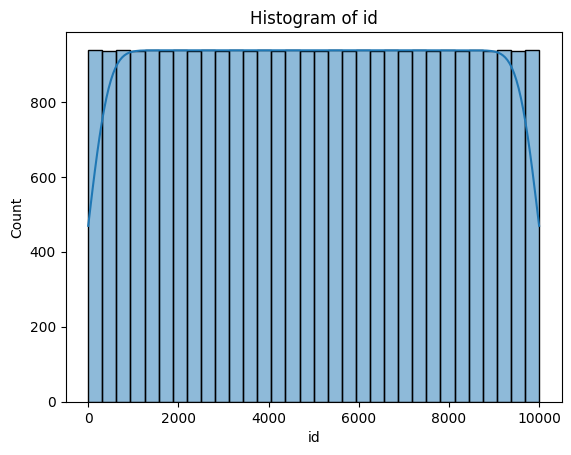

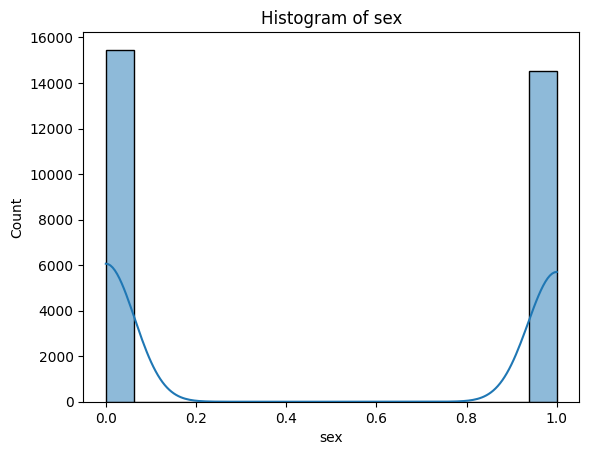

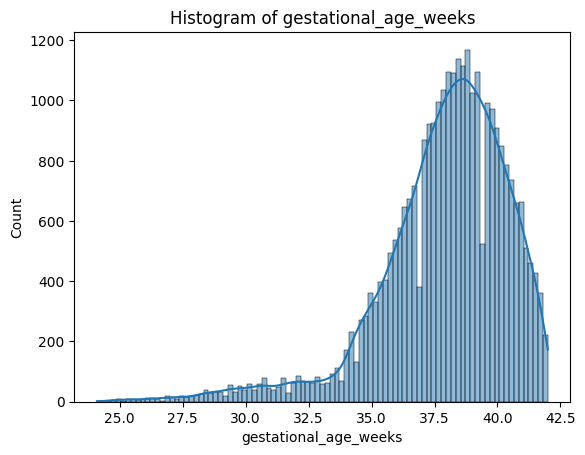

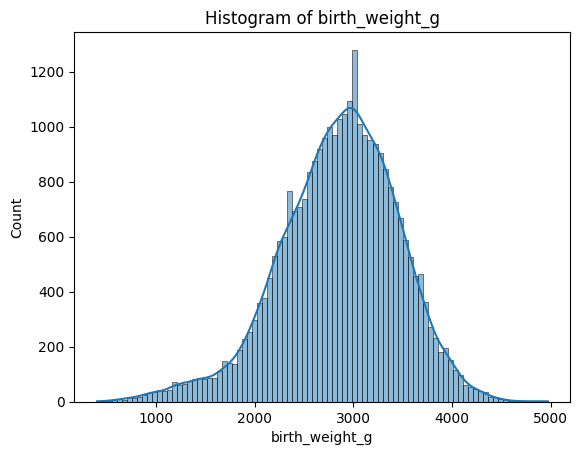

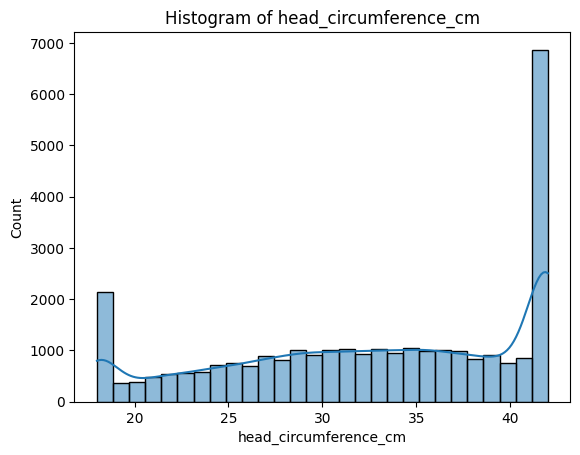

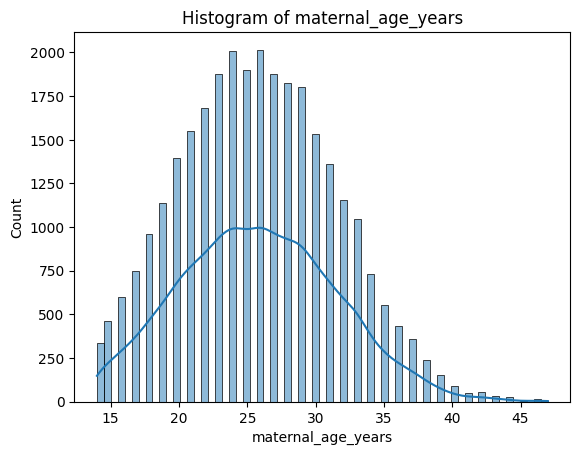

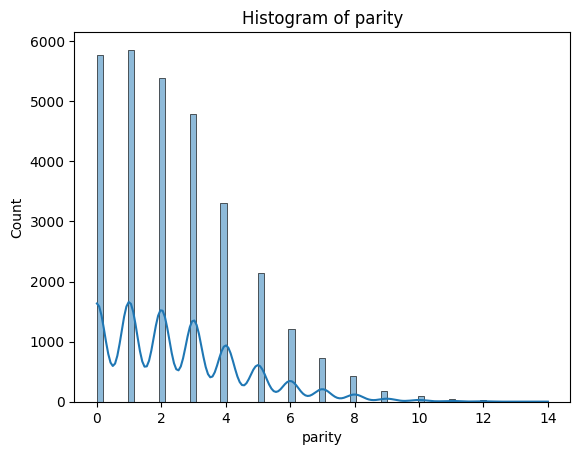

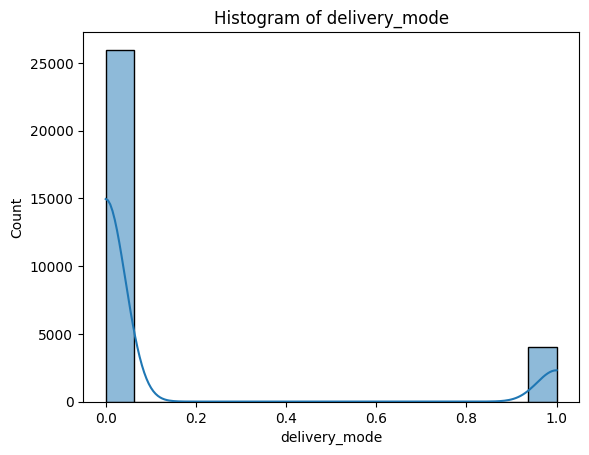

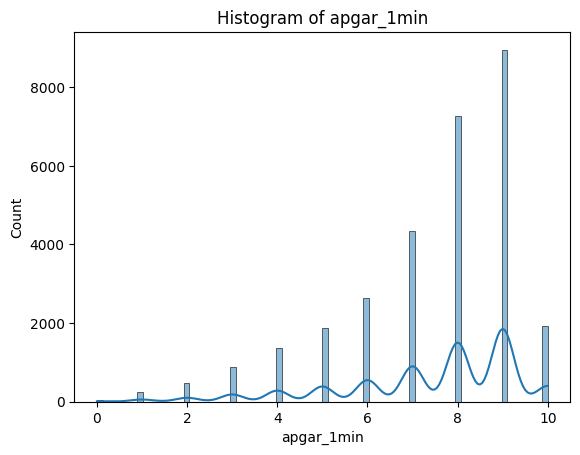

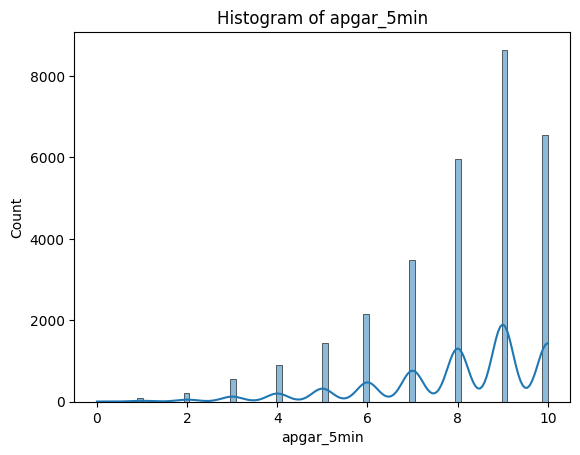

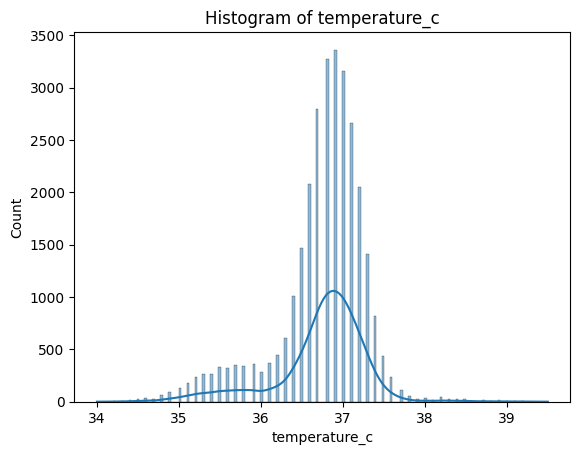

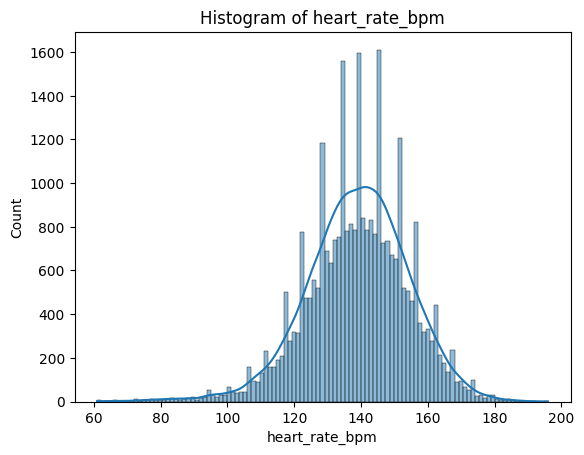

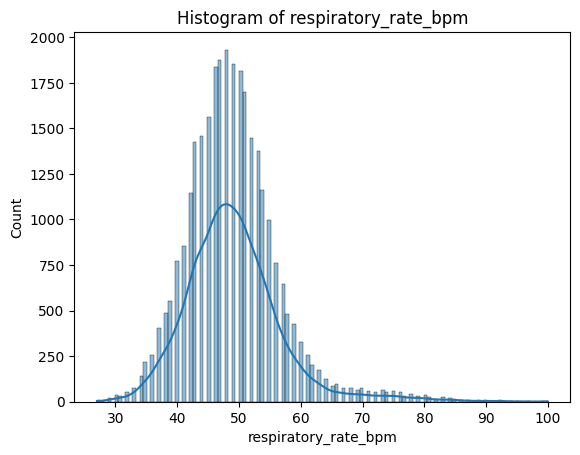

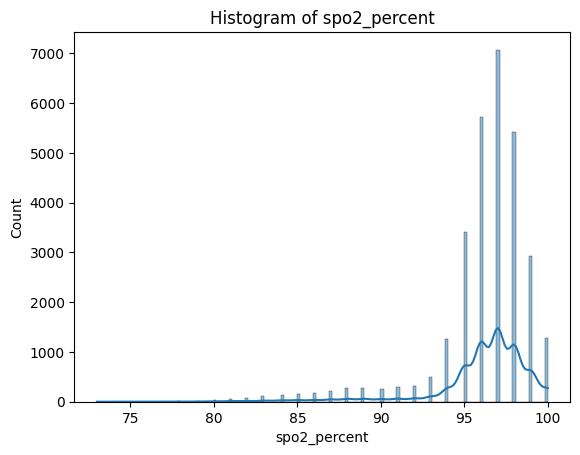

In [2545]:
#Distribution of columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

In [2546]:
#Removing ID column
df.drop("id", axis=1, inplace=True)
df.head()

,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,burden_level,primary_outcome
0,1,38.2,2730,37.0,16,0,0,9,10,36.7,147,48,96,Normal_BW,Term,moderate,healthy
1,1,39.8,2260,34.8,17,0,0,5,9,36.7,125,43,97,LBW,Term,high,low_birth_weight_term
2,1,37.1,3030,39.4,20,2,0,9,9,36.4,120,47,97,Normal_BW,Term,high,healthy
3,0,39.7,3130,18.1,15,0,0,8,10,36.8,143,54,96,Normal_BW,Term,moderate,healthy
4,0,40.5,2870,34.1,23,1,0,8,7,37.2,108,46,97,Normal_BW,Term,low,low_birth_weight_term


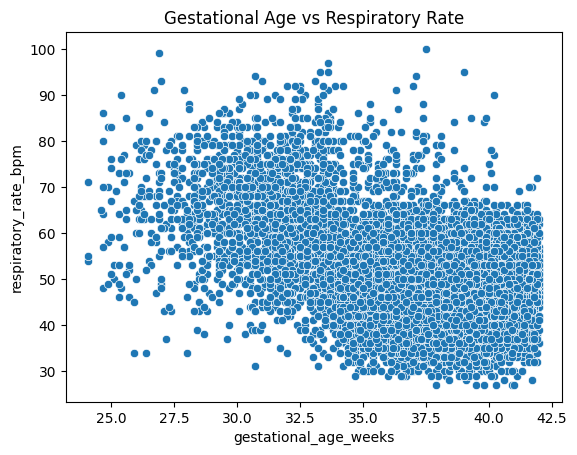

In [2547]:
#Relationship between gestational age in weeks and respiratory rate 
sns.scatterplot(x="gestational_age_weeks", y="respiratory_rate_bpm", data=df)
plt.title("Gestational Age vs Respiratory Rate")
plt.show()

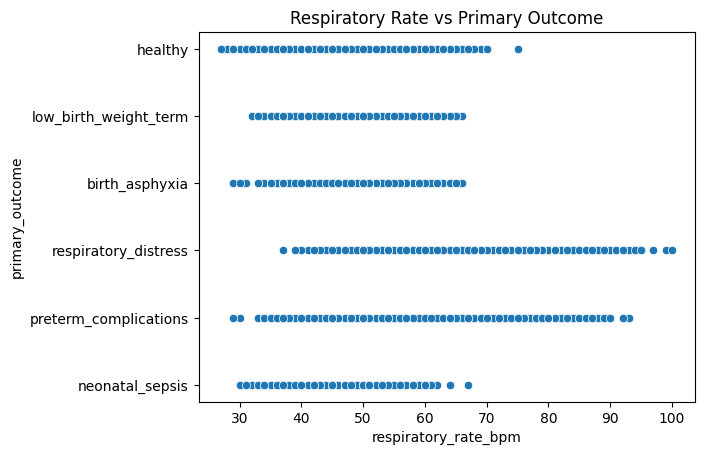

In [2548]:
# Relationship between respiratory rate and primary outcome
sns.scatterplot(x="respiratory_rate_bpm", y="primary_outcome", data=df)
plt.title("Respiratory Rate vs Primary Outcome")
plt.show()


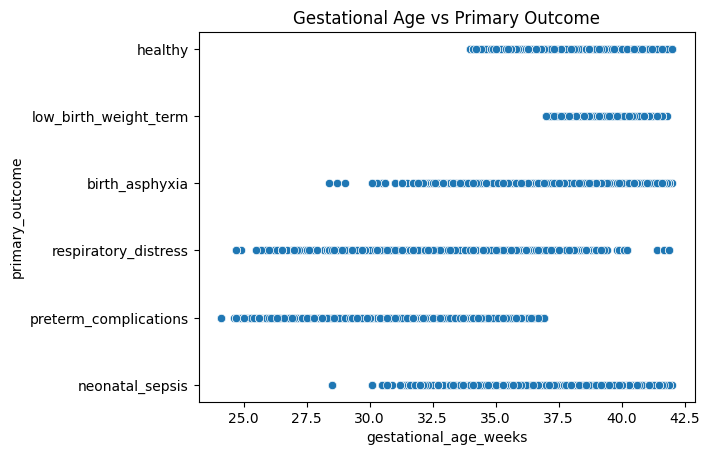

In [2549]:
#Relationship between primary outcome and gestational age in weeks
sns.scatterplot(x="gestational_age_weeks", y="primary_outcome", data=df)
plt.title("Gestational Age vs Primary Outcome")
plt.show()

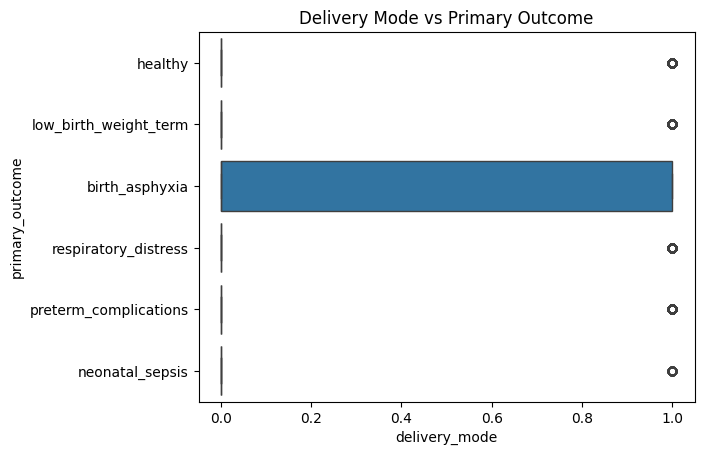

In [2550]:
# Relationship betweeen delivery mode and primary outcome
sns.boxplot(x="delivery_mode", y="primary_outcome", data=df)
plt.title("Delivery Mode vs Primary Outcome")
plt.show()

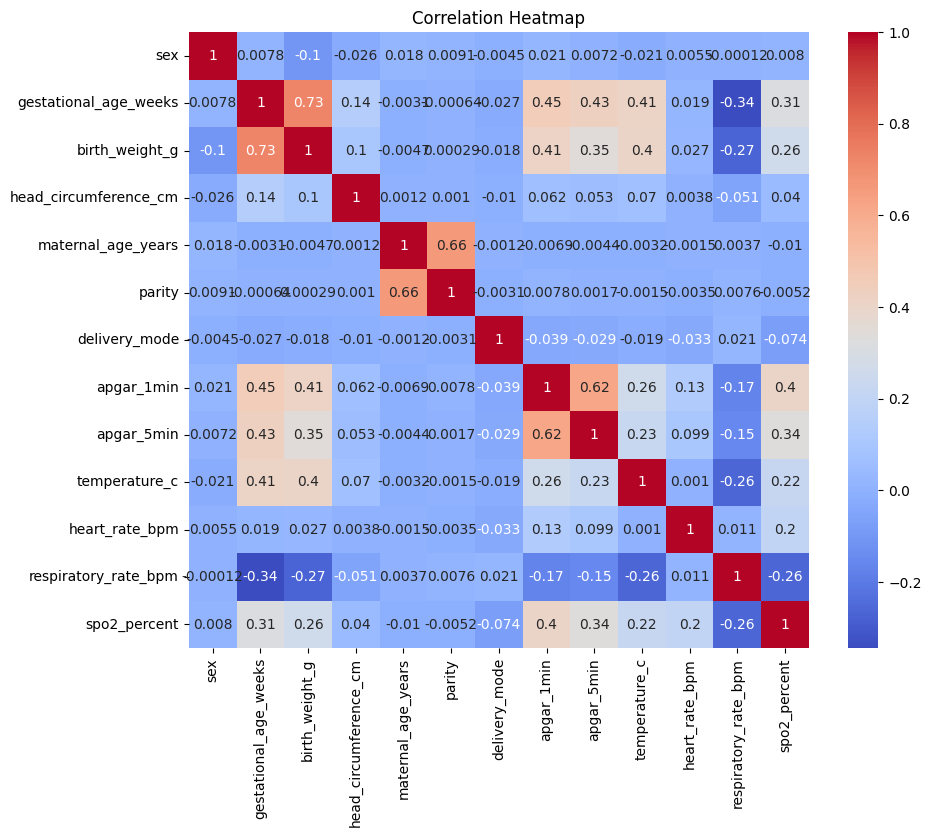

In [2551]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [2552]:
#Convert primary_outcome to numerical values
df["primary_outcome"] = df["primary_outcome"].map({"respiratory_distress": 1, "healthy": 0, "preterm_complications":0, "neonatal_sepsis":0, "low_birth_weight_term":0, "birth_asphyxia":0})
df.head()

,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,burden_level,primary_outcome
0,1,38.2,2730,37.0,16,0,0,9,10,36.7,147,48,96,Normal_BW,Term,moderate,0
1,1,39.8,2260,34.8,17,0,0,5,9,36.7,125,43,97,LBW,Term,high,0
2,1,37.1,3030,39.4,20,2,0,9,9,36.4,120,47,97,Normal_BW,Term,high,0
3,0,39.7,3130,18.1,15,0,0,8,10,36.8,143,54,96,Normal_BW,Term,moderate,0
4,0,40.5,2870,34.1,23,1,0,8,7,37.2,108,46,97,Normal_BW,Term,low,0


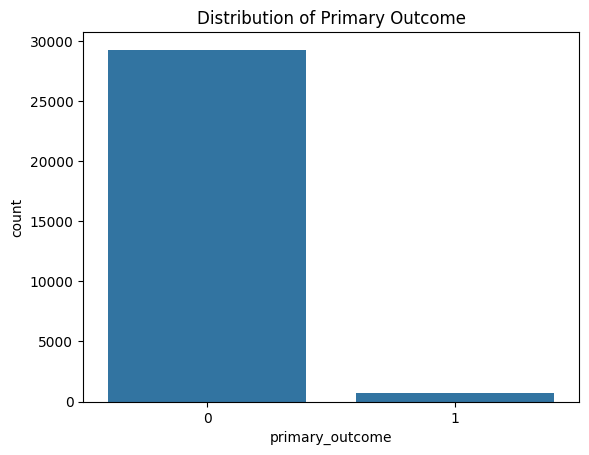

In [2553]:
#Distribution of primary outcome
sns.countplot(x="primary_outcome", data=df)
plt.title("Distribution of Primary Outcome")
plt.show()

In [2554]:
df['primary_outcome'].value_counts()

primary_outcome
0    29266
1      734
Name: count, dtype: int64

In [2555]:
#Remove the burden column 
df.drop("burden_level", axis=1, inplace=True)
df.head()

,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome
0,1,38.2,2730,37.0,16,0,0,9,10,36.7,147,48,96,Normal_BW,Term,0
1,1,39.8,2260,34.8,17,0,0,5,9,36.7,125,43,97,LBW,Term,0
2,1,37.1,3030,39.4,20,2,0,9,9,36.4,120,47,97,Normal_BW,Term,0
3,0,39.7,3130,18.1,15,0,0,8,10,36.8,143,54,96,Normal_BW,Term,0
4,0,40.5,2870,34.1,23,1,0,8,7,37.2,108,46,97,Normal_BW,Term,0


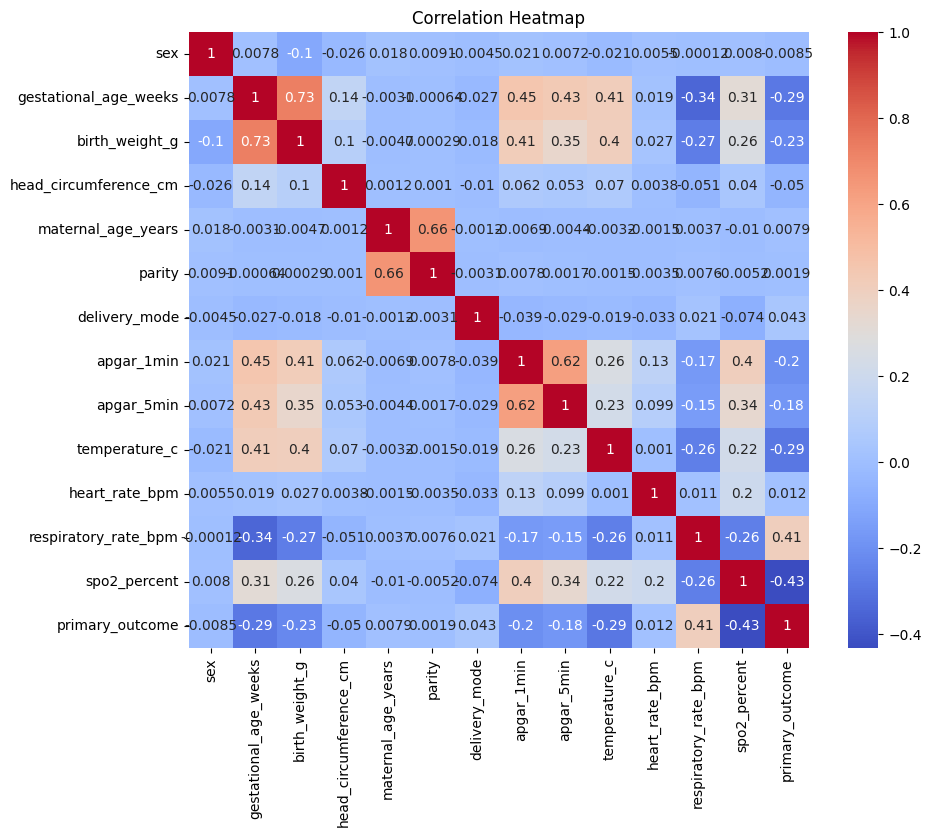

In [2556]:
#Correlation between primary outcome and other features
numeric_cols = df.select_dtypes(include="number").columns.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [2557]:
#Splitting training and testing data
X = df.drop('primary_outcome', axis=1)
y = df['primary_outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [2558]:
#Joining X_train and y_train for undersampling
train_df = pd.concat([X_train, y_train], axis=1)

In [2559]:
#Separating the majority and minority classes
rd = train_df[train_df['primary_outcome'] == 1]
other = train_df[train_df['primary_outcome'] == 0]

In [2560]:
#Undersampling training data 
other_downsampled = resample(
    other,
    replace=False,
    n_samples=len(rd),   # match minority class size (respiratory_distress)
    random_state=42
)

In [2561]:
#Combining the undersampled data with respiratory distress data
train_balanced = pd.concat([rd, other_downsampled])

train_balanced = train_balanced.sample(frac=1, random_state=42)

In [2562]:
#Checking the distribution of primary outcome in the training data
train_balanced['primary_outcome'].value_counts()

primary_outcome
1    587
0    587
Name: count, dtype: int64

In [2563]:
#Separating target variable (primary_outcome)
X_train_balanced = train_balanced.drop('primary_outcome', axis=1)
y_train_balanced = train_balanced['primary_outcome']

In [2564]:
#Getting dummy variables from categorical data
categorical_cols = X_train_balanced.select_dtypes(include='object').columns.tolist()
X_train_balanced = pd.get_dummies(X_train_balanced, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)
X_train_balanced, X_test = X_train_balanced.align(X_test, join='left', axis=1, fill_value=0)

In [2565]:
#Training XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.6,
    colsample_bytree=0.8,
    random_state=40,
    eval_metric="logloss" 
)

xgb_model.fit(X_train_balanced, y_train_balanced)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [2566]:
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [2567]:
y_pred = (y_prob > 0.65).astype(int)

In [2568]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      5853
           1       0.37      0.98      0.54       147

    accuracy                           0.96      6000
   macro avg       0.69      0.97      0.76      6000
weighted avg       0.98      0.96      0.97      6000



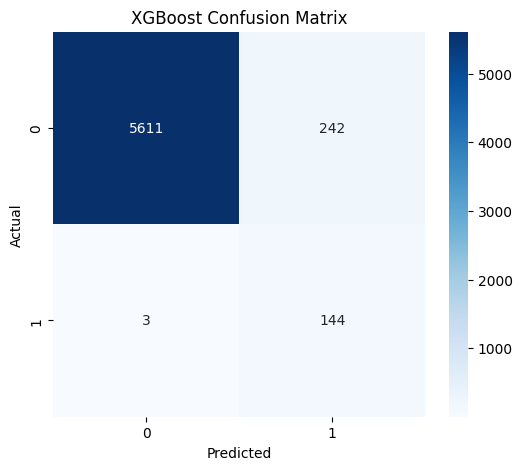

In [2569]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [2570]:
#Receiver Operating Characteristic - Area Under the Curve (ROC-AUC)
roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.9912237575706858


<Figure size 800x600 with 0 Axes>

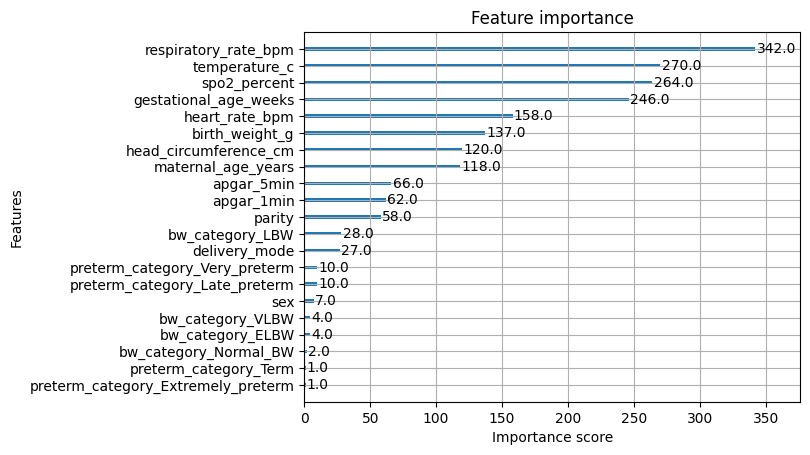

In [2571]:
#Feature importance plot
plt.figure(figsize=(8,6))
plot_importance(xgb_model)
plt.show()

In [2572]:
#Training Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=280,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=450,
    class_weight="balanced"
)

rf_model.fit(X_train_balanced, y_train_balanced)

,n_estimators,280
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [2573]:
#Predicting with Random Forest Classifier
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [2574]:
#Classification report for Random Forest Classifier
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      5853
           1       0.31      0.99      0.48       147

    accuracy                           0.95      6000
   macro avg       0.66      0.97      0.72      6000
weighted avg       0.98      0.95      0.96      6000



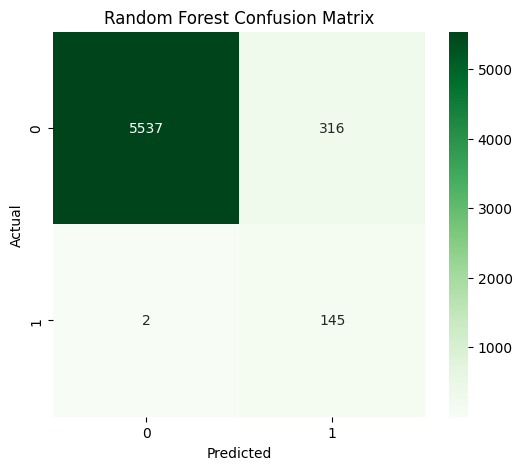

In [2575]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [2576]:
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_rf)

Random Forest ROC-AUC: 0.988384931966978


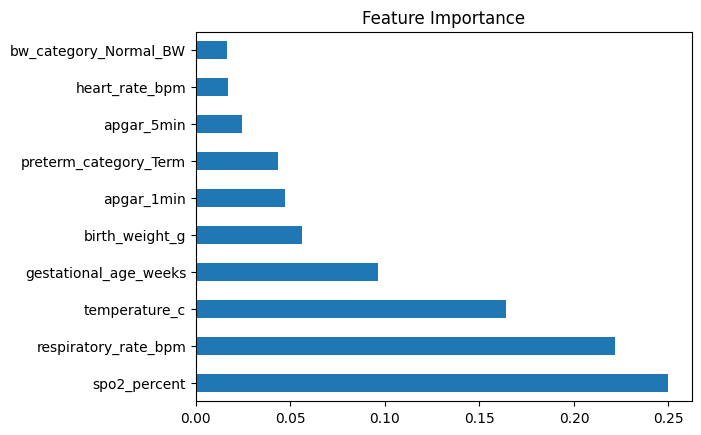

In [2577]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_balanced.columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind="barh")
plt.title("Feature Importance")
plt.show()